# Model Testing

In this notebook we can use pre-fitted models created previously and test prediction accuracy on the most up to date version of the database.

# Loading Libraries

We import a suite of modules as in `predicting_succes.ipynb`.

In [1]:
# We will obtain data from the SQlite database.
import sqlite3

# We will use functions we have previously created.
import sj_db_functions as dbfunc

# We will use the following for handling data and creating figures and charts.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# We use the following for preprocessing data and evaluating models.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.base import clone

# We employ a suite of models to determine which may work best.
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# We use pickle to save the best model.
import pickle

# We set the seed for replicability.
np.random.seed(2)


# Loading a model

We can load a classifier from the corresponding folder using pickle.

In [2]:
with open(r'classifiers\demos\03_03_2026_logisticregression.pkl', 'rb') as f:
    loader = pickle.load(f)
loader

{'Model': Pipeline(steps=[('Preprocess',
                  ColumnTransformer(force_int_remainder_cols=False,
                                    remainder='passthrough',
                                    transformers=[('OneHotEncoding',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False),
                                                   ['genre', 'release_month']),
                                                  ('Scaler', StandardScaler(),
                                                   ['average_placement',
                                                    'color_pages', 'batch_size',
                                                    'place_chap_1',
                                                    'place_chap_2',
                                                    'place_chap_3',
                                                    'place_ch...
  

As we can see the pickle file contains a dictionary with the following keys:

In [3]:
loader.keys()

dict_keys(['Model', 'Fitted On', 'Success Criteria', 'Basis Size'])

For convenience we can separate out the contents of this dictionary.

In [4]:
basis_size=loader['Basis Size']
success_criteria=loader['Success Criteria']
# Displaying the basis size and success criteria of the saved model.
(basis_size,success_criteria)

(12, 50)

In [5]:
fitted_on=loader['Fitted On']
fitted_on

['Shadow Eliminators',
 'Martial Master Asumi',
 'Psych House',
 "Ichigoki's Under Control!!",
 'Two on Ice',
 'Do Retry',
 'Shinobi Undercover',
 'Ultimate Exorcist Kiyoshi',
 'Aliens Area',
 'Kagurabachi',
 'Astro Royale',
 'Kaedegami',
 'Ice-Head Gill',
 'Ekiden Bros',
 'Hakutaku',
 'Kyokuto Necromance',
 'Tokyo Demon Bride Story',
 'Earthchild',
 'Nice Prison',
 "The Ichinose Family's Deadly Sins",
 'Syd Craft: Love Is a Mystery',
 'Fabricant 100',
 'Ping-Pong Peril',
 'Green Green Greens',
 'Ginka & Glüna',
 'Kill Blue',
 'MamaYuyu',
 'Akane-banashi',
 'Embers',
 'Cipher Academy',
 "Nue's Exorcist"]

In [6]:
loaded_model=loader['Model']
loaded_model

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('OneHotEncoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['genre', 'release_month']),
                                                 ('Scaler', StandardScaler(),
                                                  ['average_placement',
                                                   'color_pages', 'batch_size',
                                                   'place_chap_1',
                                                   'place_chap_2',
                                                   'place_chap_3',
                                                   'place_ch...
                                                   'place_chap_11',
                                                   'place_chap_12']),
                                                 ('Column Dropper', 'drop',
                                                  ['title', 'cover_pages',
                                                   'release_year'])],
                                   verbose_feature_names_out=False)),
                ('FeatureSelection',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('DropMost', 'passthrough',
                                                  ['average_placement',
                                                   'color_pages'])],
                                   verbose_feature_names_out=False)),
                ('Classifier', LogisticRegression(max_iter=500))])

The model was a logistic regression classifier (as we could also tell from the file name).

# Obtaining Data

We will use data taken from our SQLite database. We can load modeling data easily using `dbfunc`.

In [7]:
# We connect to the most recent copy of the database.
connection=sqlite3.connect('shonen_jump.sqlite3')
cursor=connection.cursor()
# Displaying the earliest and latest recorded dates in the database.
cursor.execute("""SELECT MIN(release_date), MAX(release_date) FROM chapters;""")
date_range=cursor.fetchone()
print(f"When this notebook was last run the demo database contained chapters between {date_range[0]} and {date_range[1]}.")

When this notebook was last run the demo database contained chapters between 2022-01-16 and 2025-11-09.


If we want only the average placements of series over the first $x$ chapters we can use dbfunc's average_placements function.

In [8]:
# Loading the average placement of series over the first 20 chapters.
simple=dbfunc.average_placements(connection, 20,include_canceled=True)
simple

,title,average_placement
0,Akane-banashi,7.600000
1,Aliens Area,14.300000
2,Astro Royale,11.050000
3,Cipher Academy,12.250000
4,Dear Anemone,14.294118
5,Do Retry,15.263158
6,Earthchild,12.900000
7,Ekiden Bros,14.882353
8,Embers,15.350000
9,Fabricant 100,13.400000


We can add a column which tracks the success or failure of a series using the corresponding function and specifying a success criteria and list of titles.

In [9]:
# Here we consider series which ran for at least 50 chapters to be successes.
success=dbfunc.success_or_failure(connection,success_criteria=50,titles=simple['title'].to_list())
success

,title,success
0,Akane-banashi,1.0
1,Aliens Area,0.0
2,Astro Royale,1.0
3,Cipher Academy,1.0
4,Dear Anemone,0.0
5,Do Retry,0.0
6,Earthchild,0.0
7,Ekiden Bros,0.0
8,Embers,0.0
9,Fabricant 100,0.0


We can merge the two resulting dataframes on their titles.

In [10]:
simple_df=simple.merge(success,left_on='title',right_on='title')
simple_df

,title,average_placement,success
0,Akane-banashi,7.600000,1.0
1,Aliens Area,14.300000,0.0
2,Astro Royale,11.050000,1.0
3,Cipher Academy,12.250000,1.0
4,Dear Anemone,14.294118,0.0
5,Do Retry,15.263158,0.0
6,Earthchild,12.900000,0.0
7,Ekiden Bros,14.882353,0.0
8,Embers,15.350000,0.0
9,Fabricant 100,13.400000,0.0


The success column may contain NaN values.  We can manually adjust these if we know the total chapters a series ran for even if the database doesn't contain all the chapters yet.  In this case, given the success criteria we chose, both NaN values should be replaced by 0.

In [11]:
simple_df['success']=simple_df['success'].fillna(0).astype(int)
simple_df

,title,average_placement,success
0,Akane-banashi,7.600000,1
1,Aliens Area,14.300000,0
2,Astro Royale,11.050000,1
3,Cipher Academy,12.250000,1
4,Dear Anemone,14.294118,0
5,Do Retry,15.263158,0
6,Earthchild,12.900000,0
7,Ekiden Bros,14.882353,0
8,Embers,15.350000,0
9,Fabricant 100,13.400000,0


We will use this dataframe more later.  For now we will also load more complex data that can be used with the model we loaded earlier.  In this case we can use the `load_modeling_data` function.  We will use the basis size and success criteria we obtained earlier from the pickle file.

In [12]:
complex_data=dbfunc.load_modeling_data(connection,basis_size)
complex_data

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12,release_year,release_month
0,Akane-banashi,Other,0,7.750000,2.0,1,2,1,6,11,...,11,8,12,9,8,10,4,6,2022,2
1,Aliens Area,Battle,1,11.416667,2.0,1,3,1,6,8,...,8,10,10,13,17,19,20,18,2022,6
2,Astro Royale,Battle,1,8.500000,2.0,1,3,1,4,11,...,9,10,6,6,8,11,15,16,2024,4
3,Cipher Academy,Other,0,10.250000,1.0,1,4,1,5,11,...,12,8,14,12,13,13,14,12,2022,11
4,Dear Anemone,Battle,1,12.250000,1.0,1,2,1,6,10,...,10,9,12,17,17,18,20,19,2024,2
5,Do Retry,Sports,1,13.000000,1.0,1,4,1,4,8,...,12,11,17,17,19,20,21,21,2023,5
6,Earthchild,Other,1,9.666667,2.0,1,2,1,6,11,...,12,8,13,12,7,11,13,14,2022,2
7,Ekiden Bros,Sports,1,12.666667,1.0,1,4,1,7,10,...,12,16,8,10,20,19,20,20,2025,6
8,Embers,Sports,0,12.500000,1.0,1,2,1,6,10,...,7,12,11,16,17,20,19,19,2025,2
9,Fabricant 100,Battle,1,11.250000,1.0,1,4,1,6,10,...,9,14,11,11,15,14,16,16,2022,12


In [13]:
success_column=dbfunc.success_or_failure(connection,success_criteria=success_criteria,titles=complex_data['title'].to_list())
df=complex_data.merge(success_column,left_on='title',right_on='title')
df

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12,release_year,release_month,success
0,Akane-banashi,Other,0,7.750000,2.0,1,2,1,6,11,...,8,12,9,8,10,4,6,2022,2,1.0
1,Aliens Area,Battle,1,11.416667,2.0,1,3,1,6,8,...,10,10,13,17,19,20,18,2022,6,0.0
2,Astro Royale,Battle,1,8.500000,2.0,1,3,1,4,11,...,10,6,6,8,11,15,16,2024,4,1.0
3,Cipher Academy,Other,0,10.250000,1.0,1,4,1,5,11,...,8,14,12,13,13,14,12,2022,11,1.0
4,Dear Anemone,Battle,1,12.250000,1.0,1,2,1,6,10,...,9,12,17,17,18,20,19,2024,2,0.0
5,Do Retry,Sports,1,13.000000,1.0,1,4,1,4,8,...,11,17,17,19,20,21,21,2023,5,0.0
6,Earthchild,Other,1,9.666667,2.0,1,2,1,6,11,...,8,13,12,7,11,13,14,2022,2,0.0
7,Ekiden Bros,Sports,1,12.666667,1.0,1,4,1,7,10,...,16,8,10,20,19,20,20,2025,6,0.0
8,Embers,Sports,0,12.500000,1.0,1,2,1,6,10,...,12,11,16,17,20,19,19,2025,2,0.0
9,Fabricant 100,Battle,1,11.250000,1.0,1,4,1,6,10,...,14,11,11,15,14,16,16,2022,12,0.0


In [14]:
# We close the connection now that we have obtained all the information from the database we need.
connection.close()

# Making Predictions with a Prefit Model

We will use the more complex data (from `df`) to make predictions using the model we loaded.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              41 non-null     object 
 1   genre              41 non-null     object 
 2   one_creator        41 non-null     int64  
 3   average_placement  41 non-null     float64
 4   color_pages        41 non-null     float64
 5   cover_pages        41 non-null     int64  
 6   batch_size         41 non-null     int64  
 7   place_chap_1       41 non-null     int32  
 8   place_chap_2       41 non-null     int32  
 9   place_chap_3       41 non-null     int32  
 10  place_chap_4       41 non-null     int32  
 11  place_chap_5       41 non-null     int32  
 12  place_chap_6       41 non-null     int32  
 13  place_chap_7       41 non-null     int32  
 14  place_chap_8       41 non-null     int32  
 15  place_chap_9       41 non-null     int32  
 16  place_chap_10      41 non-nu

The only NaN values occur in the success column.  We can see if those rows should be dropped or if we know the actual success of those series.

In [16]:
df[df['success'].isna()][['title','success']]

,title,success
13,Harukaze Mound,NaN
26,Otr of the Flame,NaN


As before by cross-checking the total chapters in real time we can update the NaN values (in this case with 0 for both).

In [17]:
df['success']=df['success'].fillna(0).astype(int)
df

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12,release_year,release_month,success
0,Akane-banashi,Other,0,7.750000,2.0,1,2,1,6,11,...,8,12,9,8,10,4,6,2022,2,1
1,Aliens Area,Battle,1,11.416667,2.0,1,3,1,6,8,...,10,10,13,17,19,20,18,2022,6,0
2,Astro Royale,Battle,1,8.500000,2.0,1,3,1,4,11,...,10,6,6,8,11,15,16,2024,4,1
3,Cipher Academy,Other,0,10.250000,1.0,1,4,1,5,11,...,8,14,12,13,13,14,12,2022,11,1
4,Dear Anemone,Battle,1,12.250000,1.0,1,2,1,6,10,...,9,12,17,17,18,20,19,2024,2,0
5,Do Retry,Sports,1,13.000000,1.0,1,4,1,4,8,...,11,17,17,19,20,21,21,2023,5,0
6,Earthchild,Other,1,9.666667,2.0,1,2,1,6,11,...,8,13,12,7,11,13,14,2022,2,0
7,Ekiden Bros,Sports,1,12.666667,1.0,1,4,1,7,10,...,16,8,10,20,19,20,20,2025,6,0
8,Embers,Sports,0,12.500000,1.0,1,2,1,6,10,...,12,11,16,17,20,19,19,2025,2,0
9,Fabricant 100,Battle,1,11.250000,1.0,1,4,1,6,10,...,14,11,11,15,14,16,16,2022,12,0


If we only want to consider the success of predictions on data the model hasn't been trained on we can cut down in advance.

In [21]:
cut_down=df[~df['title'].isin(fitted_on)]
cut_down

,title,genre,one_creator,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,...,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12,release_year,release_month,success
4,Dear Anemone,Battle,1,12.250000,1.0,1,2,1,6,10,...,9,12,17,17,18,20,19,2024,2,0
13,Harukaze Mound,Sports,0,9.833333,2.0,1,4,1,6,10,...,13,7,10,13,13,11,13,2025,6,0
14,Hima-Ten!,Romance,1,7.833333,2.0,1,3,1,4,7,...,13,11,4,10,5,11,11,2024,7,1
16,Ichi the Witch,Battle,0,5.916667,3.0,1,3,1,4,8,...,7,6,7,4,2,5,5,2024,9,1
26,Otr of the Flame,Battle,1,11.166667,1.0,1,2,1,4,10,...,10,10,11,12,18,20,19,2025,5,0
31,Star of Beethoven,Other,1,12.250000,1.0,1,2,1,4,6,...,13,13,15,19,18,18,19,2025,2,0
32,Super Psychic Policeman Chojo,Comedy,1,6.583333,3.0,1,2,1,4,12,...,8,7,7,13,3,5,2,2024,2,1
33,Super Smartphone,Other,0,9.583333,2.0,1,3,1,6,6,...,11,11,9,15,12,13,14,2022,5,0
35,Tenmaku Cinema,Other,0,11.500000,1.0,1,4,1,4,8,...,6,14,16,18,20,19,17,2023,4,0
40,Yokai Buster Murakami,Comedy,1,17.500000,1.0,1,3,1,4,20,...,21,22,22,22,20,20,19,2024,6,0


In [22]:
X=cut_down.drop(columns='success')
y=cut_down['success']

In [23]:
loaded_model.score(X,y)

1.0

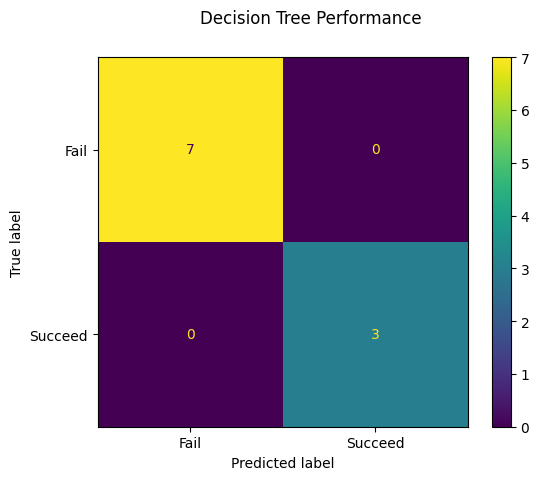

In [24]:
# Defining the matrix.
c_matrix = metrics.confusion_matrix(y, loaded_model.predict(cut_down), labels=[0,1])

# Setting the display options.
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = c_matrix, display_labels = ['Fail', 'Succeed'])
cm_display.plot()
# Adding a title.
plt.gcf().suptitle('Decision Tree Performance')
# Removing grid lines for clarity.
plt.grid(False)
plt.show()